# Task 5 - Time series forecasting

### Deadline Tuesday, July 16, 2025 at 11:59 p.m.

# IMPORTANT SUBMISSION INSTRUCTIONS

- When you're done, download the notebook and rename it to task5_name.ipynb
- Only submit the `ipynb` file, no other file is required.
- The deadline is strict.
- Minimal requirement for passing: solving all code cells.

Implementation
- Do not change the cells which are marked as "Do not change", similarly write your solution to the marked cells.

# Introduction

This task is an introduction to time series forecasting using deep neural networks with application to flood prediction. You will build a few different styles of models including Convolutional and Recurrent Neural Networks (CNNs and RNNs).

The objectives are:
- Working with time series data.
- Learning about data windowing.
- Developing different models for time series forecasting:
    - Single-step predictions
    - Multi-step predictions
- Implementing residual LSTM


## Tutorials

Some python libraries are required to accomplish the tasks assigned in this homework. If you feel like you need to follow a tutorial before, feel free to do so:

*   [Scikit-learn Tutorials](https://www.tensorflow.org/tutorials)
*   [TensorFlow Tutorials](https://scikit-learn.org/stable/tutorial/index.html)
*   [Matplotlib Tutorials](https://matplotlib.org/stable/tutorials/index.html)

## Imports

In [ ]:
import numpy as np
import random
import pandas as pd
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, losses, metrics, callbacks
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 24
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## System checks


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print(gpus)
print(cpus)

Choose your device for computation. CPU or one of your CUDA devices

In [ ]:
tf.config.set_visible_devices(gpus, 'GPU')

# Subtask 5.1

## Data pre-processing

In this task, we work with time series data of water level (W), and mass flow rate (Q) at **Margarethenklippe** and **Sennhuette**. We will develop models for forecasting these time series with the objective of developing a warning system for flood events. The time series have been collected with a time resolution of 15 minutes.
Let us load the dataset:

In [ ]:
data_dir = './'
df = pd.read_csv(data_dir + 'Flood_Data.csv', delimiter=';')
df.dropna(axis=1, inplace=True)

date_time = df[['Datum', 'Zeit']].rename(columns = {'Datum': 'Date', 'Zeit': 'Time'})
df.drop(columns=['Datum', 'Zeit', ' GranetalsperreMin15Niederschlag', ' HahnenkleeMin15Niederschlag'], inplace=True)

Here we only work with water level and mass flow rate and drop the information regarding precipitation. As you can see we also extracted the date-time variables. Let us rename the variables for simplicity.

In [ ]:
df = df.rename(columns={' MargarethenklippeMin15W': 'Mar. W',
                   ' MargarethenklippeMin15Q': 'Mar. Q',
                   ' SennhuetteMin15W': 'Sen. W',
                   ' SennhuetteMin15Q': 'Sen. Q'})

Let's take a glance at the data. Here are the first few rows:

In [ ]:
df.head()


### Removing noise

Sensor measurements may be contaminated with noise, and in practice, it is beneficial to remove the noise using a filter as a pre-processing step. Here, we will use Savitzky-Golay filter to eliminate noise in a signal and improve the smoothness of a signal trend. The filter calculates a polynomial fit of each window based on a polynomial degree and a window size. Let us employ the SciPy implementation of this filter from `scipy.signal.savgol_filter`.

In [ ]:
from scipy.signal import savgol_filter
keys = df.keys()
df = pd.DataFrame(savgol_filter(df, 49, 2, axis = 0), columns=keys)

Here we will deal with **two-hourly predictions**, so start by sub-sampling the data from 15-minute intervals to two-hour intervals:

In [ ]:
date_time_str = date_time['Date'] + ' ' + date_time['Time'].replace('24:00:00', '00:00:00')
datetime_object = pd.to_datetime(date_time_str, format = '%d.%m.%Y %H:%M:%S')

df = df[7::8].reset_index(drop=True)
datetime_object = datetime_object[7::8].reset_index(drop=True)

datetime_object.head()

Here is the evolution of a few features over time:

In [ ]:
plot_cols = ['Mar. W', 'Sen. W']
plot_features = df[plot_cols]
plot_features.index = datetime_object
_ = plot_features.plot(subplots=True)

plot_features = df[plot_cols][60000:60500]
plot_features.index = datetime_object[60000:60500]
_ = plot_features.plot(subplots=True)


The evident peak in the data in the year 2017 shows the flood event in Goslar.

### Split the data

You'll use a `(70%, 20%, 10%)` split for the training, validation, and test sets. 
This includes the flood event in Goslar in the test dataset. Note the data is **not** being randomly shuffled before splitting. This is for two reasons:

1. It ensures that chopping the data into windows of consecutive samples is still possible.
2. It ensures that the validation/test results are more realistic, being evaluated on the data collected after the model was trained.


In [ ]:
####################
## YOUR CODE HERE ##
####################

### Scale the data using min-max to [0, 1]


In [ ]:
####################
## YOUR CODE HERE ##
####################

# Subtask 5.2

## Data windowing

The models in this task will make a set of predictions based on a window of consecutive samples from the data. 

The main features of the input windows are:

- The width (number of time steps) of the input and label windows.
- The time offset between them.
- Which features are used as inputs, labels, or both. 

In this task you will develop a variety of models (including MLP, CNN and RNN models), and uses them for both:

- *Single-time-step* predictions,
- *Multi-time-step* predictions.

We will consider a sequence of time steps $X_n = [x_n, ..., x_{\ell+n}]$ with the length of $\ell$ as an input sample. In *single-time-step* predictions, we are looking for a neural network that maps this input the target time step $x_{\ell+n+o}$ where $o$ is the time offset.

1. For example, to make a single prediction 24 hours into the future, given 24 hours of history, you might define a window like this:

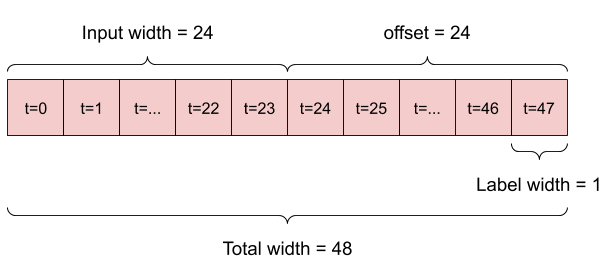

2. A model that makes a prediction one hour into the future, given six hours of history, would need a window like this:

![image]( 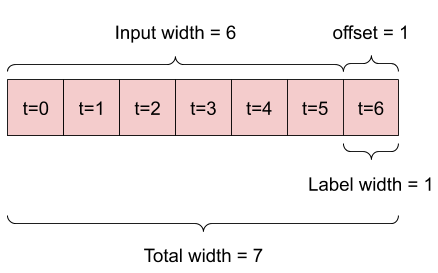)

#### Tutorial
- You may use `tf.keras.utils.timeseries_dataset_from_array` for generating sequences from time series.
https://www.tensorflow.org/api_docs/python/tf/keras/utils/timeseries_dataset_from_array

Let us develop a `WindowGenerator` class. This class can:

1. Handle the indexes and offsets as shown in the diagrams above.
1. Split windows of features into `(features, labels)` pairs.
2. Report the size of the resulting features and labels.
3. Efficiently generate batches of these windows from the training, evaluation, and test data, using `tf.data.Dataset`s.

We start by creating the `WindowGenerator` class. The `__init__` method includes all the necessary logic for the inputs and labels.

It also takes the training, evaluation, and test DataFrames as input. These will be converted to `tf.data.Dataset`s of windows later.

In [ ]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}'])
  
  def split_window(self, features):
    inputs = features[:, self.input_slice, :]
    labels = features[:, self.labels_slice, :]
    
    # Slicing doesn't preserve static shape information, so set the shapes
    # manually. This way the `tf.data.Datasets` are easier to inspect.
    inputs.set_shape([None, self.input_width, None])
    labels.set_shape([None, self.label_width, None])

    return inputs, labels

  def make_dataset(self, data, set):
    if set == 'test':
      shuffle = False
    else:
      shuffle = True

    data = np.array(data, dtype=np.float32)
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=self.total_window_size,
        sequence_stride=1,
        shuffle=shuffle,
        seed = 123,
        batch_size=32)

    ds = ds.map(self.split_window)

    return ds
  
  @property
  def train(self):
    return self.make_dataset(self.train_df, 'train')

  @property
  def val(self):
    return self.make_dataset(self.val_df, 'val')

  @property
  def test(self):
    return self.make_dataset(self.test_df, 'test')

#### TODO
- Using the `WindowGenerator` class, pre-process the data for a model that takes one day of data as the input and predicts two hours in the future.
- Takes 3 samples from the training dataset and visualize the input sequence and the target label (for one of the variables).

In [ ]:
####################
## YOUR CODE HERE ##
####################

### Plot

Let us also define a function that takes the window class and the model and plot the reference and predicted water level in **Margarethenklippe** for a span of time corresponding to the flood in 2017.

In [ ]:
def plot_predictions(Window, model, column = 'Mar. W'):
    l = Window.input_width + Window.shift 
    start = 2346 - l + 1
    end = start + 12
    label_index = column_indices[column]
    _, labels = zip(*Window.test)
    preds = model.predict(Window.test)
    labels = np.concatenate([l.numpy() for l in labels])
    y = labels[start:end][:, -1, label_index]
    yp = preds[start:end][:, -1, label_index]
    t = np.arange(0, 24, 2)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(t, y, '-o', c='tab:blue', label = 'Reference')
    ax.plot(t, yp, '--x', c='tab:red', label = 'Prediction')
    ax.set_ylabel(column)
    ax.set_xlabel('Time [h]')
    ax.set_ylim(0.5, 2.2)
    ax.legend(frameon = False)

# Single-time-step predictions

# Subtask 5.3

# Baseline

Before building a trainable model it would be good to have a performance baseline as a point for comparison with the later more complicated models.

This first task is to predict all features two hours into the future, given the current value of all features. 

#### TODO

- So, start with a model that just returns the current values as the prediction, predicting "No change". Of course, this baseline will work less well if you make a prediction further in the future.
- Compute the mean-squared and mean-absolute errors for the validation and test datasets.
- Store the errors in a dictionary, so that at the end you could compare all the models you are going to develop.
- Use the `plot_predictions` function and visualize the results.


In [ ]:
# Window Generator

####################
## YOUR CODE HERE ##
####################

In [ ]:
# Model 
####################
## YOUR CODE HERE ##
####################

In [ ]:
# Training and evaluation
####################
## YOUR CODE HERE ##
####################

val_performance = {}
performance = {}
val_performance['Baseline'] = ...
performance['Baseline'] = ...


In [ ]:
# Plot
####################
## YOUR CODE HERE ##
####################

# Subtask 5.4

## Single-step Dense

### Dense

Before applying models that actually operate on multiple time-steps, it's worth checking the performance of deeper, more powerful, single input step models.

#### TODO

- Use the `WindowGenerator` class and consider a model that takes a time step as the input and predicts the next time step.
- Implement a model using `Dense` layers.
- Train the model for 20 epochs.
- Compute the mean-squared and mean-absolute errors for the validation and test datasets.
- Store the errors, so that at the end you could compare the models.
- Use the `plot_predictions` function and visualize the results.


Note that the `WindowGenerator` class will return the `inputs` with the shape of `(batch size, input width, number of features)`. Consider using flattening and reshaping layers properly. For instance, the dense layer does not need the sequence with dimension, so you need to flatten the data. 

Moreover, the `WindowGenerator` class will return the `labels` with the shape of `(batch size, label width, number of features)`. Consider using reshaping layers properly, so the model is passing the same shape at the output.

In [ ]:
####################
## YOUR CODE HERE ##
####################

In [ ]:
####################
## YOUR CODE HERE ##
####################

In [ ]:
####################
## YOUR CODE HERE ##
####################

# Subtask 5.5

## Multi-step Dense

A single-time-step model has no context for the current values of its inputs. It can't see how the input features are changing over time. To address this issue the model needs access to multiple time steps when making predictions:

The `baseline` and `dense` models handled each time step independently. Here the model will take multiple time steps as input to produce a single output.

#### TODO

- Create a `WindowGenerator` that will produce batches of one-day inputs and two-hour labels.
    - Note that the `Window`'s `shift` parameter is relative to the end of the two windows.
- Implement a model using `Dense` layers.
- Train the model for 20 epochs.
- Compute the mean-squared and mean-absolute errors for the validation and test datasets.
- Store the errors, so that at the end you could compare the models.
- Use the `plot_predictions` function and visualize the results.



In [ ]:
####################
## YOUR CODE HERE ##
####################

You could train a `dense` model on a multiple-input-step window by adding a `tf.keras.layers.Flatten` as the first layer of the model:

In [ ]:
####################
## YOUR CODE HERE ##
####################

In [ ]:
####################
## YOUR CODE HERE ##
####################

# Subtask 5.6

## CNN

 
A convolution layer (`tf.keras.layers.Conv1D`) also takes multiple time steps as input to each prediction.
Try the same model as `multi_step_dense`, re-written with a convolution. 

Note the changes:
* The `tf.keras.layers.Flatten` and the first `tf.keras.layers.Dense` are replaced by a `tf.keras.layers.Conv1D`.
* The `tf.keras.layers.Reshape` is no longer necessary since the convolution keeps the time axis in its output.

#### TODO

- Use one-day inputs and two-hour labels.
- Implement a CNN model using `Conv1D` layers.
- Train the model for 20 epochs.
- Compute the mean-squared and mean-absolute errors for the validation and test datasets.
- Store the errors, so that at the end you could compare the models.
- Use the `plot_predictions` function and visualize the results.

In [ ]:
####################
## YOUR CODE HERE ##
####################


In [ ]:
####################
## YOUR CODE HERE ##
####################

# Subtask 5.7

## LSTM

A Recurrent Neural Network (RNN) is a type of neural network well-suited to time series data. RNNs process a time series step-by-step, maintaining an internal state from time-step to time-step.

You can learn more in the [Text generation with an RNN](https://www.tensorflow.org/text/tutorials/text_generation) tutorial and the [Recurrent Neural Networks (RNN) with Keras](https://www.tensorflow.org/guide/keras/rnn) guide.

In this subtask, you will use an RNN layer called Long Short-Term Memory (`tf.keras.layers.LSTM`).

An important constructor argument for all Keras RNN layers, such as `tf.keras.layers.LSTM`, is the `return_sequences` argument. This setting can configure the layer in one of two ways:

1. If `False`, the default, the layer only returns the output of the final time step, giving the model time to warm up its internal state before making a single prediction: 

2. If `True`, the layer returns an output for each input. This is useful for:
  * Stacking RNN layers. 
  * Training a model on multiple time steps simultaneously.

#### TODO

- Use one-day inputs and two-hour labels.
- Implement an RNN model using `LSTM` layers.
- Train the model for 20 epochs.
- Compute the mean-squared and mean-absolute errors for the validation and test datasets.
- Store the errors, so that at the end you could compare the models.
- Use the `plot_predictions` function and visualize the results.

In [ ]:
####################
## YOUR CODE HERE ##
####################

In [ ]:
####################
## YOUR CODE HERE ##
####################

# Subtask 5.8

## Residual connections

The `Baseline` model from earlier took advantage of the fact that the sequence doesn't change drastically from time step to time step. Every model trained so far was randomly initialized, and then had to learn that the output is a small change from the previous time step. While you can get around this issue with careful initialization, it's simpler to build this into the model structure.

It's common in time series analysis to build models that instead of predicting the next value, predict how the value will change in the next time step. Similarly, <a href="https://arxiv.org/abs/1512.03385" class="external">residual networks</a>—or ResNets—in deep learning refer to architectures where each layer adds to the model's accumulating result.

That is how you take advantage of the knowledge that the change should be small. Essentially, this initializes the model to match the `Baseline`.

It's common in time series analysis to build models that instead of predicting the next value, predict how the value will change in the next time step. Similarly, <a href="https://arxiv.org/abs/1512.03385" class="external">residual networks</a>—or ResNets—in deep learning refer to architectures where each layer adds to the model's accumulating result.

This approach can be used in conjunction with any model discussed in this task. Here, it is being applied to the LSTM model, note the use of the `tf.initializers.zeros` to ensure that the initial predicted changes are small, and don't overpower the residual connection. There are no symmetry-breaking concerns for the gradients here, since the `zeros` are only used on the last layer.

#### TODO

- Use one-day inputs and two-hour labels.
- Implement an RNN model using `LSTM` layers and residual connections.
- Train the model for 20 epochs.
- Compute the mean-squared and mean-absolute errors for the validation and test datasets.
- Store the errors, so that at the end you could compare the models.
- Use the `plot_predictions` function and visualize the results.

Let us define a residual wrapper as a `tf.keras.Model`. We only need to modify the `call` function.

In [ ]:
class ResidualWrapper(tf.keras.Model):
  def __init__(self, model):
    super().__init__()
    self.model = model

  def call(self, inputs, *args, **kwargs):
    delta = ...
    outputs = ...
    # The prediction for each time step is the input
    # from the previous time step plus the delta
    # calculated by the model.
    return ...

In [ ]:
####################
## YOUR CODE HERE ##
####################

residual_lstm = ResidualWrapper(...)

####################
## YOUR CODE HERE ##
####################


In [ ]:
####################
## YOUR CODE HERE ##
####################

# Subtask 5.9

## Multi-step models

Both the single-input and multiple-input models in the previous sections made **single time step predictions**, two hours into the future.

This subtask looks at how to expand these models to make **multiple time step predictions**.

In a multi-step prediction, the model needs to learn to predict a range of future values. Thus, unlike a single step model, where only a single future point is predicted, a multi-step model predicts a sequence of the future values.

There are two rough approaches to this:

1. Single shot predictions where the entire time series is predicted at once.
2. Autoregressive predictions where the model only makes single step predictions and its output is fed back as its input.

We will perform single shot predictions. For the multi-step model, the training data again consists of two-hourly samples. Let us train a model to predict 6 hours into the future, given 24 hours of the past.

#### TODO

- Create and use the window generator.
- Implement an RNN model using `LSTM`.
- Train the model for 20 epochs.
- Compute the mean-squared and mean-absolute errors for the validation and test datasets.
- Store the errors, so that at the end you could compare the models.
- Use the `plot_predictions` function and visualize the results.


In [ ]:
####################
## YOUR CODE HERE ##
####################

In [ ]:
####################
## YOUR CODE HERE ##
####################

In [ ]:
####################
## YOUR CODE HERE ##
####################

# Subtask 5.10

## Performance

#### TODO
- Plot the mean-absolute error on the validation and test datasets in a bar plot for all the models.
- Which one of the models is outperforming others? Why? 

In [ ]:
####################
## YOUR CODE HERE ##
####################


<span style='color:red'>**Your answer:**</span>

...